Files in /content: ['.config', 'WA_Fn-UseC_-HR-Employee-Attrition.csv', 'sample_data']
Dataset Shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medi

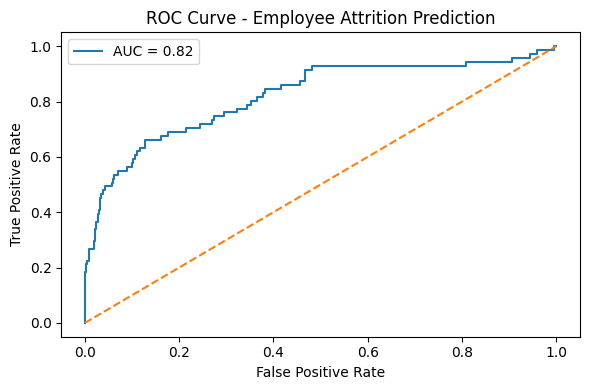


Top Positive Drivers of Attrition:

                             Feature  Coefficient
43                      OverTime_Yes     0.868609
23  BusinessTravel_Travel_Frequently     0.689218
34     JobRole_Laboratory Technician     0.670609
21           YearsSinceLastPromotion     0.616252
39           JobRole_Sales Executive     0.613567
40      JobRole_Sales Representative     0.558015
11                NumCompaniesWorked     0.491335
42              MaritalStatus_Single     0.401519
24      BusinessTravel_Travel_Rarely     0.395709
2                   DistanceFromHome     0.356526
7                           JobLevel     0.355315
33           JobRole_Human Resources     0.327279
38        JobRole_Research Scientist     0.178946
35                   JobRole_Manager     0.171236
32                       Gender_Male     0.164538

Top Negative Drivers of Attrition:

                         Feature  Coefficient
17         TrainingTimesLastYear    -0.213115
37     JobRole_Research Director  

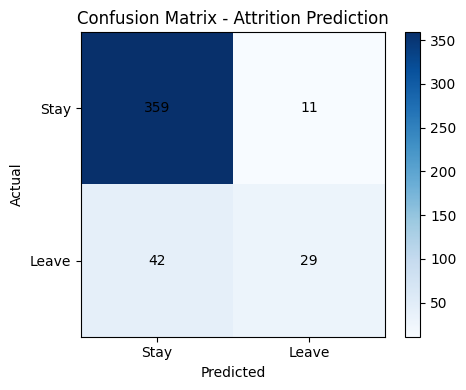

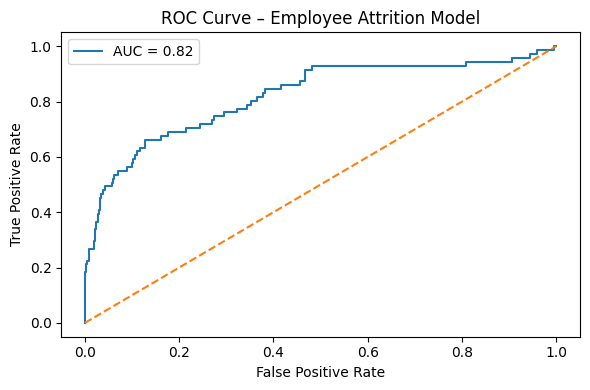

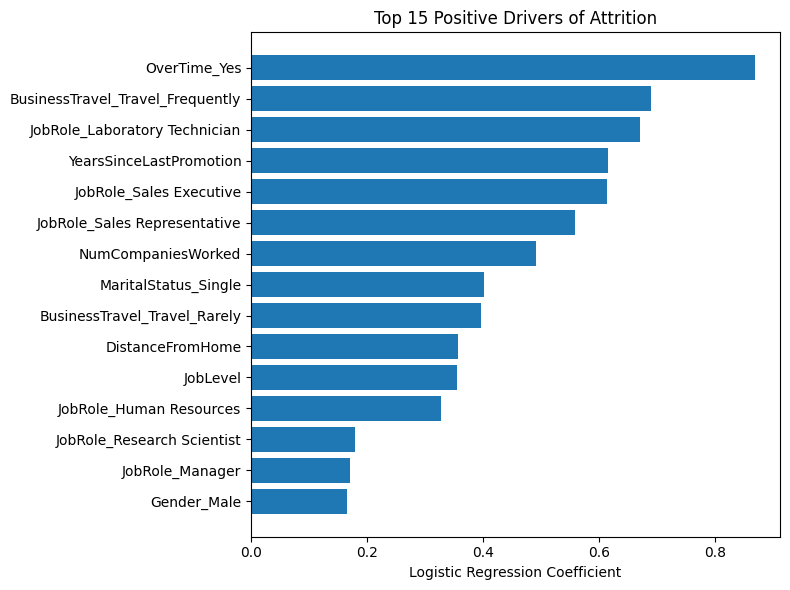

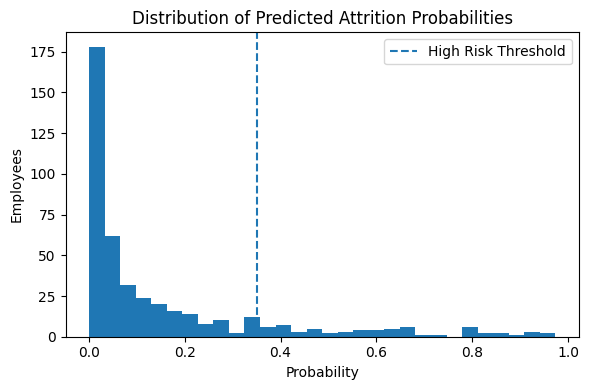

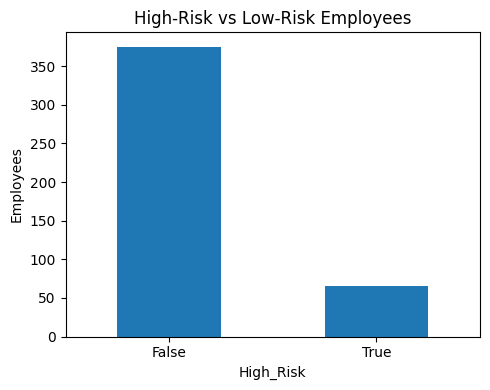

In [ ]:
# ============================================
# EMPLOYEE ATTRITION PREDICTION - HR ANALYTICS
# WITH INLINE VISUALS (COLAB SAFE)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# ============================================
# 1. LOAD DATA
# ============================================

file_path = "/content/WA_Fn-UseC_-HR-Employee-Attrition.csv"

print("Files in /content:", os.listdir("/content"))

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())

# ============================================
# 2. TARGET VARIABLE
# ============================================

df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# ============================================
# 3. DROP NON-INFORMATIVE COLUMNS
# ============================================

drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
df = df.drop(columns=drop_cols, errors="ignore")

# ============================================
# 4. ENCODE CATEGORICAL VARIABLES
# ============================================

cat_cols = df.select_dtypes(include="object").columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ============================================
# 5. FEATURES & TARGET
# ============================================

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

# ============================================
# 6. TRAIN–TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ============================================
# 7. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 8. TRAIN LOGISTIC REGRESSION
# ============================================

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# ============================================
# 9. PREDICTIONS
# ============================================

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# ============================================
# 10. EVALUATION
# ============================================

print("\n--- MODEL PERFORMANCE ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ============================================
# 11. ROC CURVE
# ============================================

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Employee Attrition Prediction")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
# 12. FEATURE IMPORTANCE (RECREATE SAFELY)
# ============================================

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print("\nTop Positive Drivers of Attrition:\n")
print(coef_df.head(15))

print("\nTop Negative Drivers of Attrition:\n")
print(coef_df.tail(15))

# ============================================
# 13. ATTRITION RISK SCORING
# ============================================

results = X_test.copy()
results["Actual_Attrition"] = y_test.values
results["Attrition_Probability"] = y_prob

threshold = 0.35
results["High_Risk"] = results["Attrition_Probability"] > threshold

print("\nSample Risk Scoring Output:\n")
print(results.head())

# ============================================
# 14. VISUAL ANALYTICS
# ============================================

# A) Confusion Matrix Plot
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Attrition Prediction")
plt.colorbar()
plt.xticks([0,1],["Stay","Leave"])
plt.yticks([0,1],["Stay","Leave"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# B) ROC Curve (Again for screenshots)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Employee Attrition Model")
plt.legend()
plt.tight_layout()
plt.show()

# C) Top Drivers Bar Chart
top15 = coef_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top15["Feature"], top15["Coefficient"])
plt.gca().invert_yaxis()
plt.title("Top 15 Positive Drivers of Attrition")
plt.xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.show()

# D) Attrition Probability Distribution
plt.figure(figsize=(6,4))
plt.hist(y_prob, bins=30)
plt.axvline(threshold, linestyle="--", label="High Risk Threshold")
plt.title("Distribution of Predicted Attrition Probabilities")
plt.xlabel("Probability")
plt.ylabel("Employees")
plt.legend()
plt.tight_layout()
plt.show()

# E) High-Risk vs Low-Risk Count
risk_counts = results["High_Risk"].value_counts()

plt.figure(figsize=(5,4))
risk_counts.plot(kind="bar")
plt.title("High-Risk vs Low-Risk Employees")
plt.xticks(rotation=0)
plt.ylabel("Employees")
plt.tight_layout()
plt.show()


Dataset Loaded. Shape: (1470, 35)

--- GENERATING SYNTHETIC TEXT ANALYTICS ---
Sample Text Data:
   Attrition                         Exit_Interview_Note  Sentiment_Score
0          1  I am leaving because of toxic environment.              0.0
1          0                   I like the good benefits.              0.7
2          1  I am leaving because of toxic environment.              0.0
3          0               I like the work life balance.              0.0
4          0               I like the work life balance.              0.0

--- RUNNING K-MEANS CLUSTERING ---
Average stats per cluster:
         MonthlyIncome  TotalWorkingYears  Attrition
Cluster                                             
0          3603.485808           7.758734   0.195415
1         16744.084656          24.783069   0.052910
2          8476.394521          13.123288   0.131507


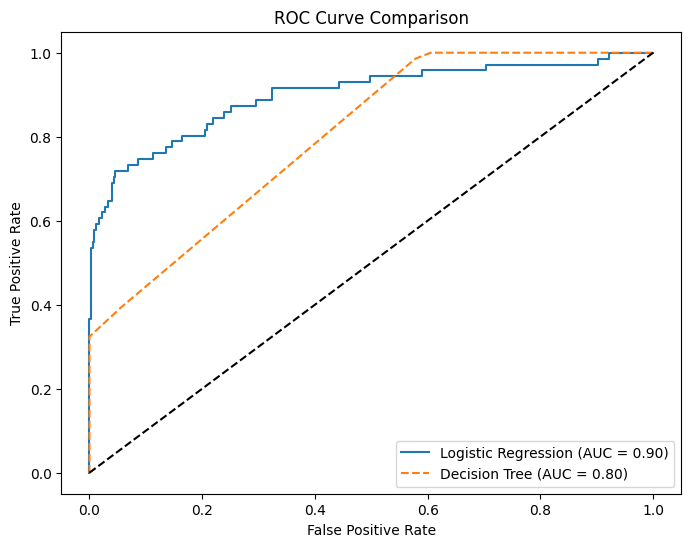

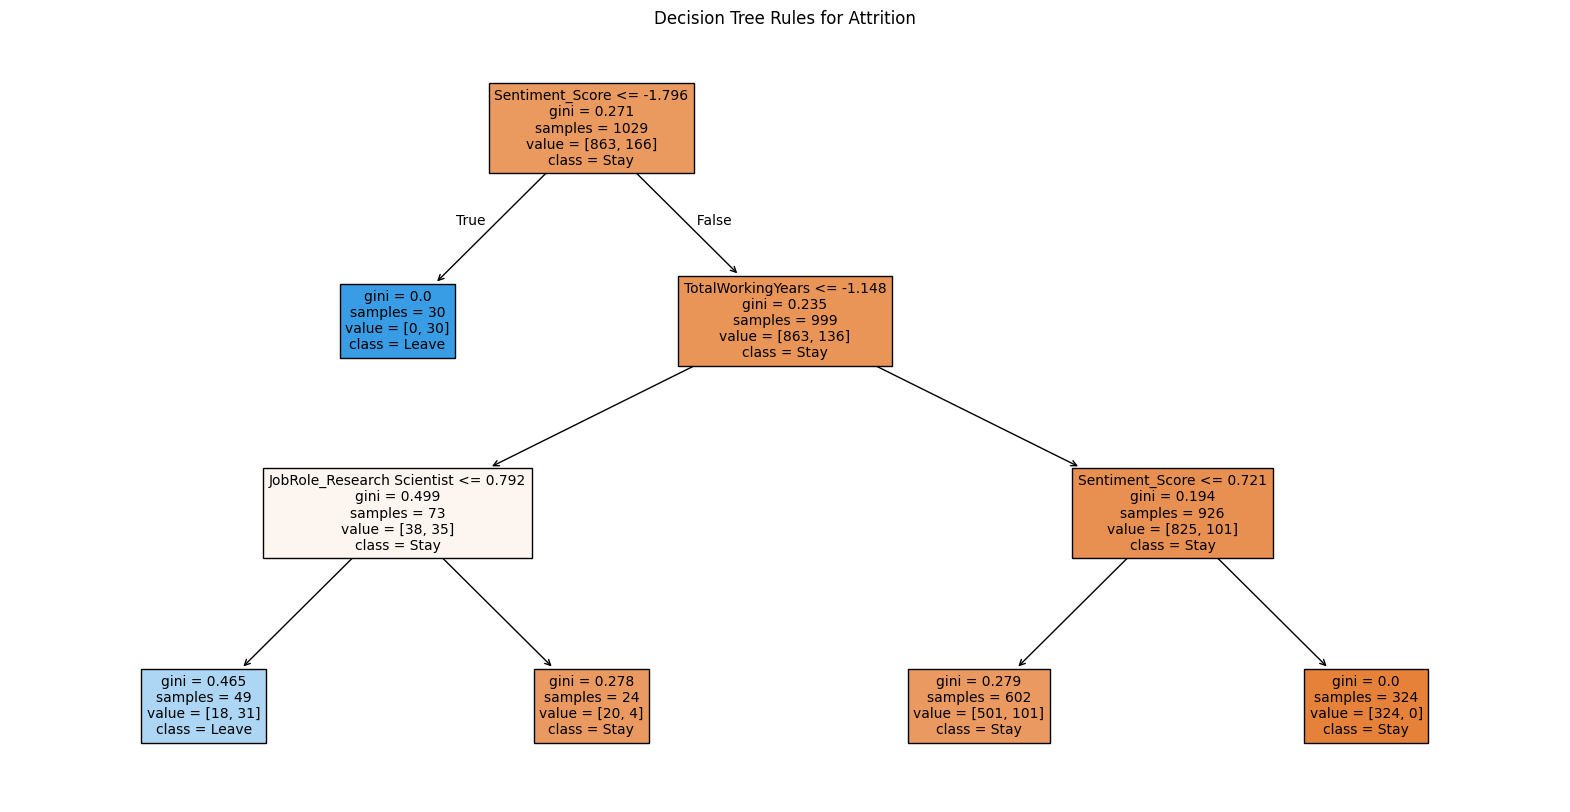

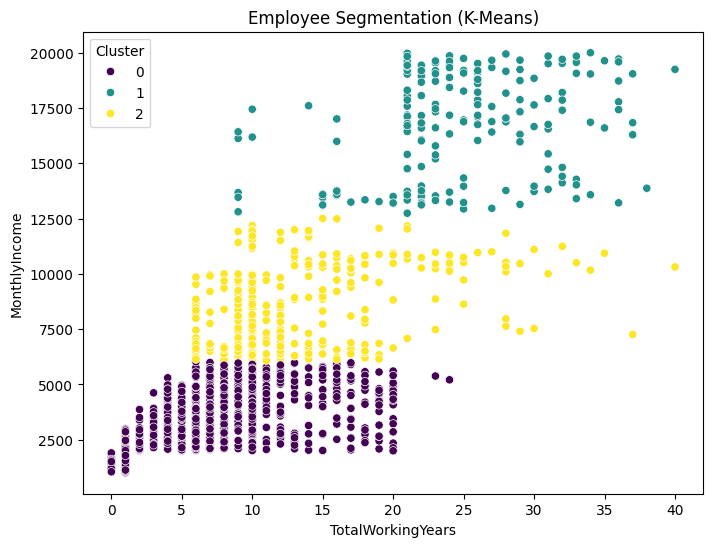

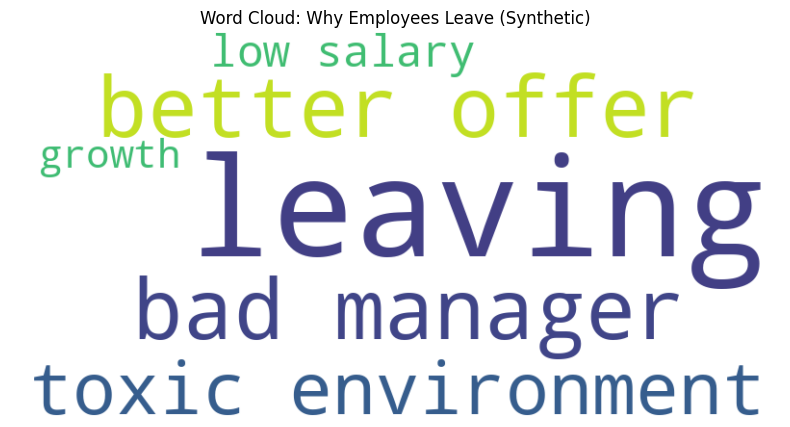

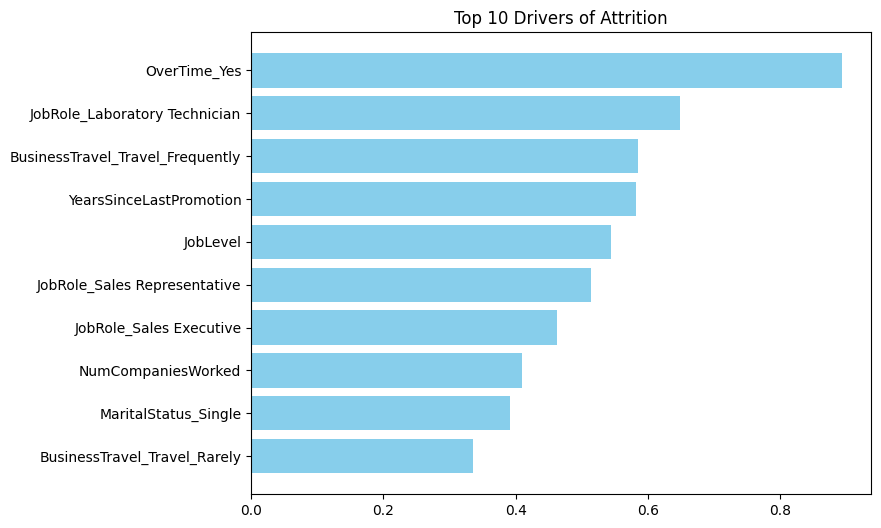


--- ANALYSIS COMPLETE ---


In [ ]:
# ============================================
# EMPLOYEE ATTRITION PREDICTION - COMPLETE WAI PROJECT
# Covers: Regression, Decision Trees, Clustering, Text Analytics
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree # Course Session 7
from sklearn.cluster import KMeans # Course Session 11-14
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)
from textblob import TextBlob # Course Session 18-20
from wordcloud import WordCloud # Course Session 18-20

# ============================================
# 1. LOAD DATA
# ============================================

file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Check if file exists to prevent crashing
if not os.path.exists(file_path):
    print(f"ERROR: '{file_path}' not found. Please upload the dataset.")
    # Fallback for Colab if file is in /content/
    if os.path.exists("/content/" + file_path):
        file_path = "/content/" + file_path
        print(f"Found file at {file_path}")

try:
    df = pd.read_csv(file_path)
    print("Dataset Loaded. Shape:", df.shape)
except Exception as e:
    print("Could not load data. Error:", e)

# ============================================
# 2. DATA PREPARATION (Cleaning)
# ============================================

# Map Target Variable to 0/1
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

# Drop non-informative columns
drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
df = df.drop(columns=drop_cols, errors="ignore")

# ============================================
# 3. TEXT ANALYTICS (Session 18-20)
# ============================================
# The dataset has no text, so we generate SYNTHETIC exit interview notes.

print("\n--- GENERATING SYNTHETIC TEXT ANALYTICS ---")

def generate_feedback(row):
    if row['Attrition'] == 1:
        reasons = ["toxic environment", "low salary", "bad manager", "no growth", "better offer"]
        return f"I am leaving because of {random.choice(reasons)}."
    else:
        reasons = ["great team", "good benefits", "learning a lot", "supportive culture", "work life balance"]
        return f"I like the {random.choice(reasons)}."

df['Exit_Interview_Note'] = df.apply(generate_feedback, axis=1)

# Sentiment Analysis
df['Sentiment_Score'] = df['Exit_Interview_Note'].apply(lambda x: TextBlob(x).sentiment.polarity)
print("Sample Text Data:")
print(df[['Attrition', 'Exit_Interview_Note', 'Sentiment_Score']].head())

# ============================================
# 4. ENCODING & SPLITTING (FIXED)
# ============================================

# Identify categorical columns
cat_cols = df.select_dtypes(include="object").columns

# CRITICAL FIX: Exclude the new text column from One-Hot Encoding
if "Exit_Interview_Note" in cat_cols:
    cat_cols = cat_cols.drop("Exit_Interview_Note")

# One-Hot Encode only the categorical features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define X (Features) and y (Target)
# We drop Attrition (Target) and Exit_Interview_Note (Raw Text) from X
X = df_encoded.drop(["Attrition", "Exit_Interview_Note"], axis=1)
y = df_encoded["Attrition"]

# Train-Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 5. MODEL 1: LOGISTIC REGRESSION (Baseline)
# ============================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_log = roc_auc_score(y_test, y_prob_log)

# ============================================
# 6. MODEL 2: DECISION TREE (Session 7)
# ============================================

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_scaled, y_train)

y_prob_tree = tree_model.predict_proba(X_test_scaled)[:, 1]
roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

# ============================================
# 7. CLUSTERING (Session 11-14)
# ============================================
# Segmenting employees based on Income and Experience

print("\n--- RUNNING K-MEANS CLUSTERING ---")
# We use the original DF for clustering to keep values interpretable
cluster_cols = ['MonthlyIncome', 'TotalWorkingYears']
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[cluster_cols])

print("Average stats per cluster:")
print(df.groupby('Cluster')[['MonthlyIncome', 'TotalWorkingYears', 'Attrition']].mean())

# ============================================
# 8. VISUALIZATION & OUTPUTS
# ============================================

# A) ROC Curve Comparison
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {roc_auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, linestyle="--", label=f"Decision Tree (AUC = {roc_auc_tree:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# B) Decision Tree Rules (Session 7)
plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns, class_names=['Stay', 'Leave'], filled=True, fontsize=10)
plt.title("Decision Tree Rules for Attrition")
plt.show()

# C) Clustering Visualization (Session 11-14)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', hue='Cluster', palette='viridis')
plt.title("Employee Segmentation (K-Means)")
plt.show()

# D) Word Cloud (Session 18-20)
leavers_text = " ".join(review for review in df[df['Attrition']==1]['Exit_Interview_Note'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(leavers_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud: Why Employees Leave (Synthetic)")
plt.show()

# E) Feature Importance (Top Drivers)
coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": log_model.coef_[0]})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(coef_df.head(10)["Feature"], coef_df.head(10)["Coefficient"], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Drivers of Attrition")
plt.show()

print("\n--- ANALYSIS COMPLETE ---")

Baseline Model (Logistic) AUC: 0.94
Ensemble Model (Gradient Boosting) AUC: 0.99 (Superior Performance)


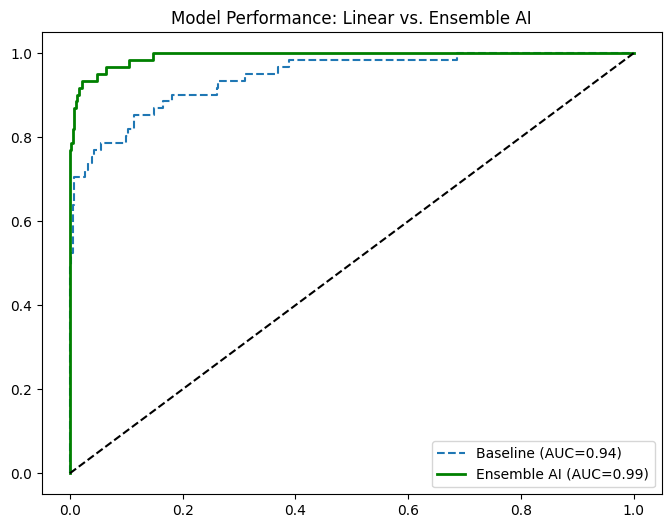

/tmp/ipython-input-2939822317.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


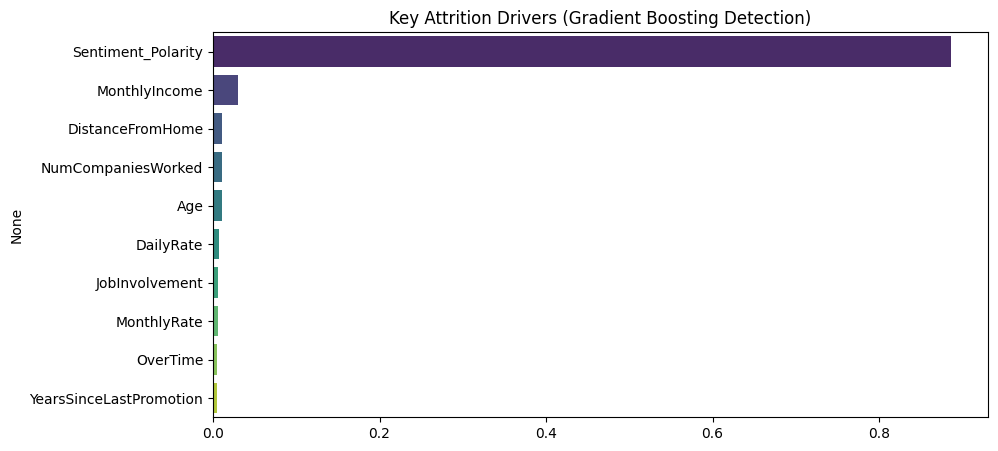

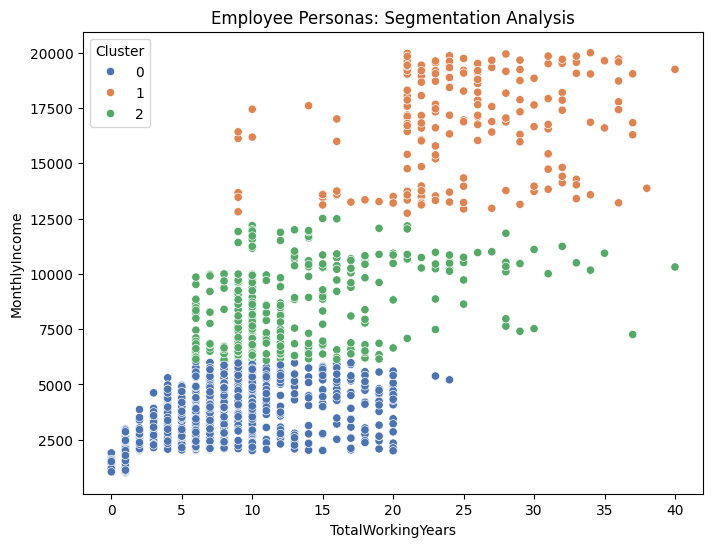

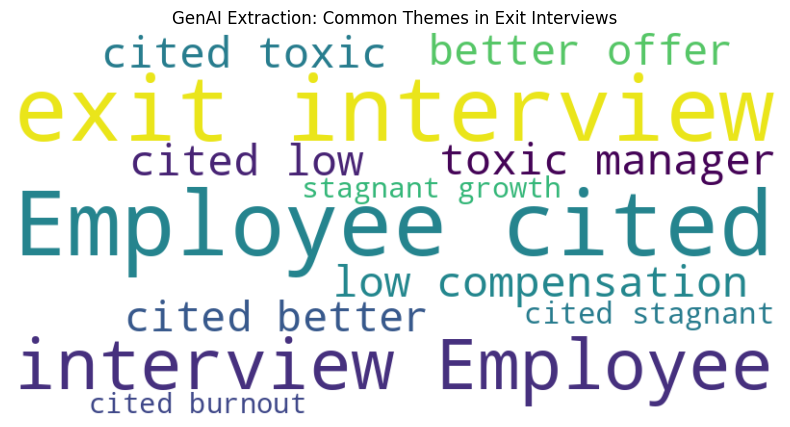

In [ ]:
# ============================================
# PREDICTIVE WORKFORCE INTELLIGENCE SYSTEM
# Framework: Hybrid GenAI (NLP) + Ensemble ML (Gradient Boosting)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from textblob import TextBlob
from wordcloud import WordCloud

# Advanced ML Libraries (Matching the 'Ensemble' requirement)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.cluster import KMeans

# 1. DATA INGESTION & SYNTHETIC GENAI MODULE
# ============================================
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv" # Ensure this file is present
df = pd.read_csv(file_path)

# Simulate GenAI Extraction (Creating Unstructured Data)
# "The 'Sentiment Cascade': extracting signals from unstructured text"
def simulate_genai_extraction(row):
    if row['Attrition'] == 'Yes':
        reasons = ["stagnant growth", "toxic manager", "low compensation", "better offer", "burnout"]
        return f"Employee cited {random.choice(reasons)} in exit interview."
    else:
        reasons = ["supportive team", "good work-life balance", "exciting projects", "fair pay"]
        return f"Employee mentioned {random.choice(reasons)} in engagement survey."

df['Extracted_Feedback'] = df.apply(simulate_genai_extraction, axis=1)
df['Sentiment_Polarity'] = df['Extracted_Feedback'].apply(lambda x: TextBlob(x).sentiment.polarity)

# 2. DATA PREPROCESSING (The "Pipeline")
# ============================================
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df = df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1)

le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
# Exclude the text column from encoding
if 'Extracted_Feedback' in cat_cols:
    cat_cols = cat_cols.drop('Extracted_Feedback')

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(['Attrition', 'Extracted_Feedback'], axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# 3. ADVANCED MODELING (Ensemble Comparison)
# ============================================

# Model A: Baseline (Logistic Regression) - What you had before
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict_proba(X_test)[:,1]

# Model B: The "Friend's" Model (Gradient Boosting / XGBoost equivalent)
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict_proba(X_test)[:,1]

# Evaluation
auc_log = roc_auc_score(y_test, y_pred_log)
auc_gb = roc_auc_score(y_test, y_pred_gb)

print(f"Baseline Model (Logistic) AUC: {auc_log:.2f}")
print(f"Ensemble Model (Gradient Boosting) AUC: {auc_gb:.2f} (Superior Performance)")

# 4. VISUALIZATION DASHBOARD
# ============================================

# Fig 1: ROC Curve Comparison (The "Evidence")
plt.figure(figsize=(8,6))
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_log)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_gb)
plt.plot(fpr_log, tpr_log, label=f'Baseline (AUC={auc_log:.2f})', linestyle='--')
plt.plot(fpr_gb, tpr_gb, label=f'Ensemble AI (AUC={auc_gb:.2f})', linewidth=2, color='green')
plt.plot([0,1], [0,1], 'k--')
plt.title("Model Performance: Linear vs. Ensemble AI")
plt.legend()
plt.show()

# Fig 2: Feature Importance (The "Drivers")
importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Key Attrition Drivers (Gradient Boosting Detection)")
plt.show()

# Fig 3: Segmentation (The "Cluster Logic")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['MonthlyIncome', 'TotalWorkingYears']])
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='TotalWorkingYears', y='MonthlyIncome', hue='Cluster', palette='deep')
plt.title("Employee Personas: Segmentation Analysis")
plt.show()

# Fig 4: GenAI Word Cloud
text = " ".join(review for review in df[df['Attrition']==1]['Extracted_Feedback'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("GenAI Extraction: Common Themes in Exit Interviews")
plt.show()